In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from sklearn import model_selection, metrics
from glob import glob
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import munch
import yaml

In [14]:
plt.style.use('default')

# Utils

In [15]:
def read_yaml(fname: str)-> munch.Munch:


    with open(fname) as fobj:
        config = yaml.safe_load(fobj)
        
    #config = munch.munchify(config)

    return config

# Imports

In [16]:
url = "https://data.up.ethz.ch/shared/OceanSODA-ETHZv2/total_alkalinity/GLODAPv2023/GLODAPv2023-raw_collocated-{y}.pq"
df = pd.concat([pd.read_parquet(url.format(y=y)) for y in range(1982, 2022)])

renaming_dict = read_yaml('/home/edupuis/highres_TA/renaming_dict.yaml')
df = df.rename(columns = renaming_dict)

# move talk column to the front
col = df.pop('talk_gp')
df.insert(0, 'talk_gp', col)

# store column names       
all_cols = df.columns.to_list()

all_time_cols = [i for i in all_cols if 'time' in i]
all_coord_cols = [i for i in all_cols if ('lat' in i or 'lon' in i or 'time' in i)]

# print info
df.info()

<class 'pandas.DataFrame'>
Index: 42134 entries, 83 to 492
Data columns (total 62 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   talk_gp                42134 non-null  float64       
 1   expocode_gp            42134 non-null  str           
 2   time_gp                42134 non-null  datetime64[ns]
 3   lat_gp                 42134 non-null  float64       
 4   lon_gp                 42134 non-null  float64       
 5   bottomdepth_gp         42134 non-null  float64       
 6   maxsampdepth_gp        41978 non-null  float64       
 7   depth_gp               42134 non-null  float64       
 8   temp_gp                41938 non-null  float64       
 9   salinity_gp            41650 non-null  float64       
 10  oxygen_gp              37673 non-null  float64       
 11  aou_gp                 37037 non-null  float64       
 12  nitrate_gp             34351 non-null  float64       
 13  nitrite_gp        

In [17]:
salinity_bin_edges = [0, 32, 34, 36, np.inf]
salinity_bin_labels = ['<32', '32-34', '34-36', '>36']
df['salinity_bin'] = pd.cut(df['salinity_gp'], bins=salinity_bin_edges, labels=salinity_bin_labels)

df = df.dropna(subset=['salinity_bin'])

In [18]:
print(df.talk_flag_gp.unique())
print(df.talk_qc_gp.unique())

[2. 0.]
[0. 1.]


# Train-test split

In [19]:
def plot_split(source_df, train_idx, test_idx, label_train = 'train', label_eval = 'test', train_color = "C0", eval_color = "C1", title = 'GLODAPv2'):

    train_expo = set(source_df.expocode_gp.iloc[train_idx].unique())
    test_expo = set(source_df.expocode_gp.iloc[test_idx].unique())
    assert len(train_expo & test_expo) == 0, "can't have overlapping expocodes in train and test sets"

    source_df.iloc[train_idx].expocode_gp.value_counts().plot(kind='hist', bins=50, alpha=0.5, label= label_train)
    source_df.iloc[test_idx].expocode_gp.value_counts().plot(kind='hist', bins=50, alpha=0.5, label=label_eval)
    plt.legend()

    split_stats = pd.concat([
        source_df['salinity_bin'].iloc[train_idx].value_counts()[salinity_bin_labels],
        source_df['salinity_bin'].iloc[test_idx].value_counts()[salinity_bin_labels], 
    ], axis=1, keys=[label_train, label_eval])

    fig, ax = plt.subplots(figsize=[12, 5])
    source_df.iloc[train_idx].plot(x='lon_gp', y='lat_gp', c=train_color, kind='scatter', alpha=0.5, label=label_train, ax=ax)
    source_df.iloc[test_idx].plot(x='lon_gp', y='lat_gp', c=eval_color, kind='scatter', alpha=0.5, label=label_eval, ax=ax)
    ax.legend()
    
    fig.suptitle(title)
    plt.tight_layout()
    
    split_stats
    
    plt.show();


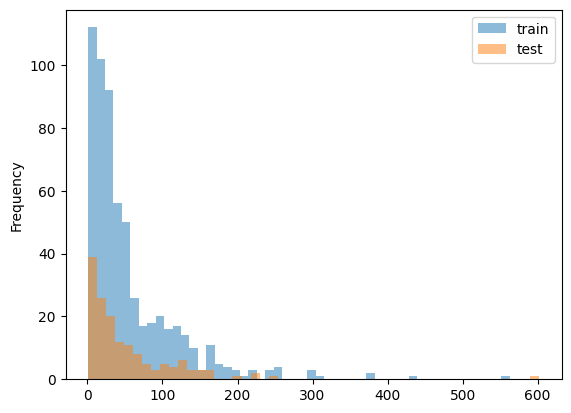

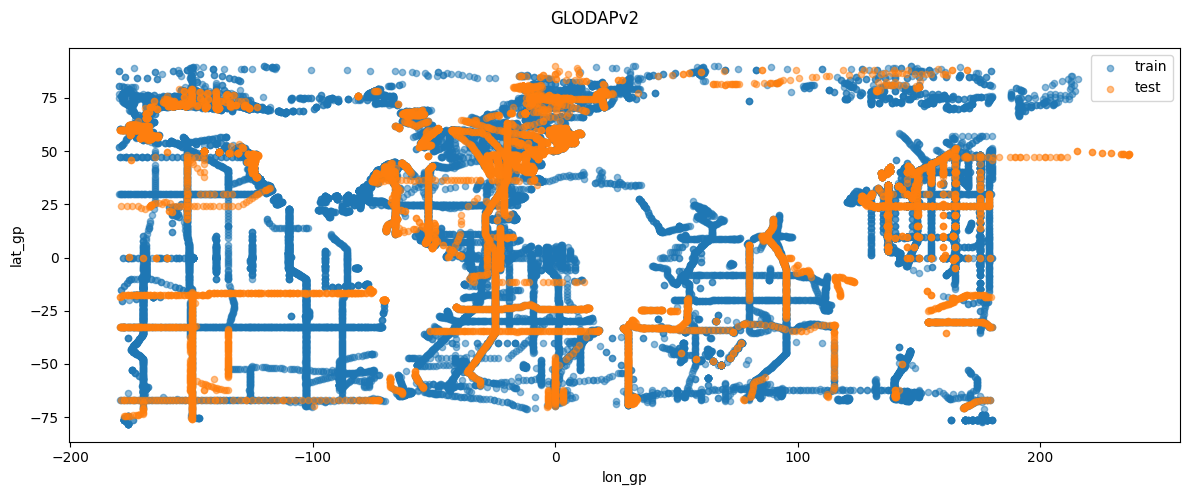

Index(['temp_gp', 'salinity_gp', 'mld_soda', 'sst_cciT', 'ice_cciT',
       'ssh_adt_cmems', 'ssh_sla_cmems', 'mld_glorys', 'chl_globcolour'],
      dtype='str')

In [20]:
# nomenclature:
# _df --> all variables
# x/y_train/test --> non predictors-labels columns removed

splitter = model_selection.StratifiedGroupKFold(n_splits=5)
splits = splitter.split(X= df, y = df['salinity_bin'], groups=df["expocode_gp"])

train_idx, test_idx = next(splits)

train_split_df = df.iloc[train_idx]
test_split_df = df.iloc[test_idx]

plot_split(source_df=df,train_idx=train_idx,test_idx=test_idx)


#clean up to useful predictors only
drop_cols = (
    ['talk_gp', 'year_gp', 'expocode_gp', 'salinity_bin', 'tco2_gp', 'fco2_gp', 'silicate_gp', 'phtsinsitutp_gp', 'oxygen_gp', 'nitrate_gp', 'nitrite_gp', 'phosphate_gp',  'aou_gp', 'salinity_soda','temp_soda'] 
    + df.filter(regex='time').columns.tolist() 
    + df.filter(regex='lat|lon').columns.tolist() 
    + df.filter(regex='uncert|error').columns.tolist()
    + df.filter(regex='depth').columns.tolist()
    + df.filter(regex='sss').columns.tolist()
    + df.filter(regex='flag').columns.tolist()
    + df.filter(regex='qc').columns.tolist()
)

x_train = train_split_df.drop(columns=drop_cols)
y_train = train_split_df['talk_gp']

x_test = test_split_df.drop(columns=drop_cols)
y_test = test_split_df['talk_gp']

x_train.columns

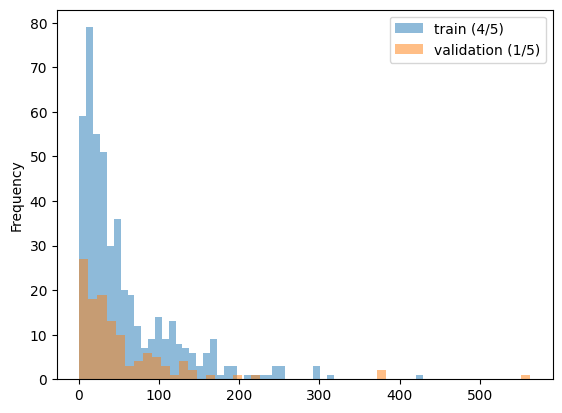

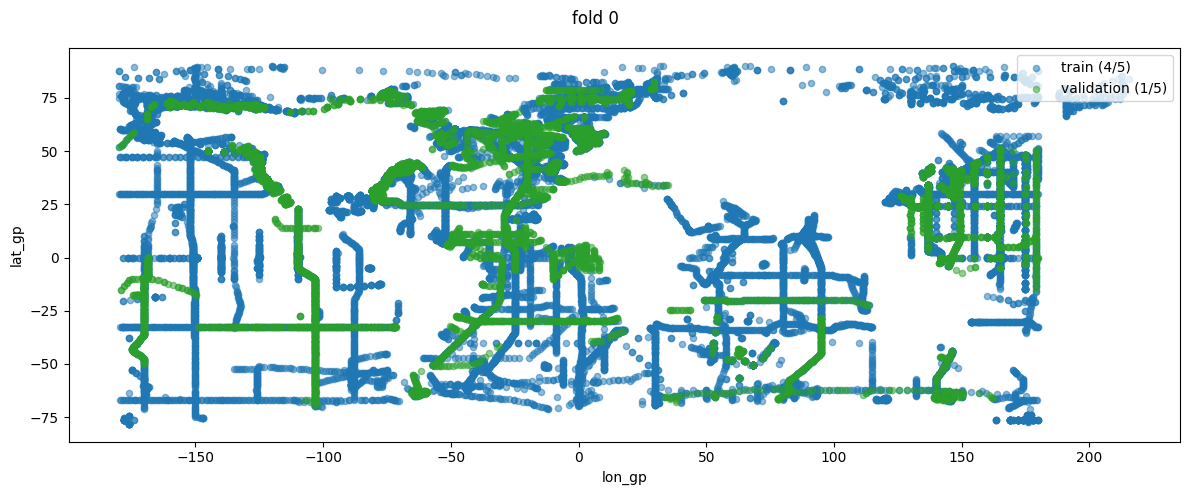

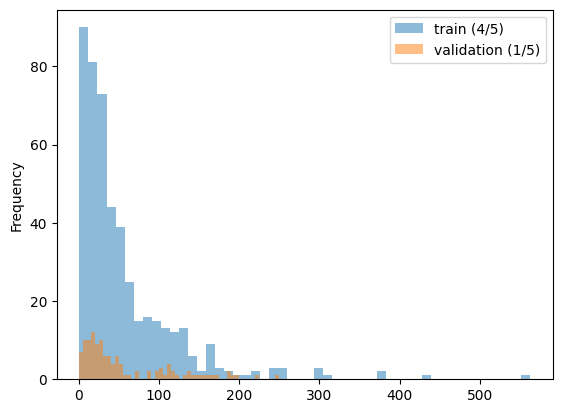

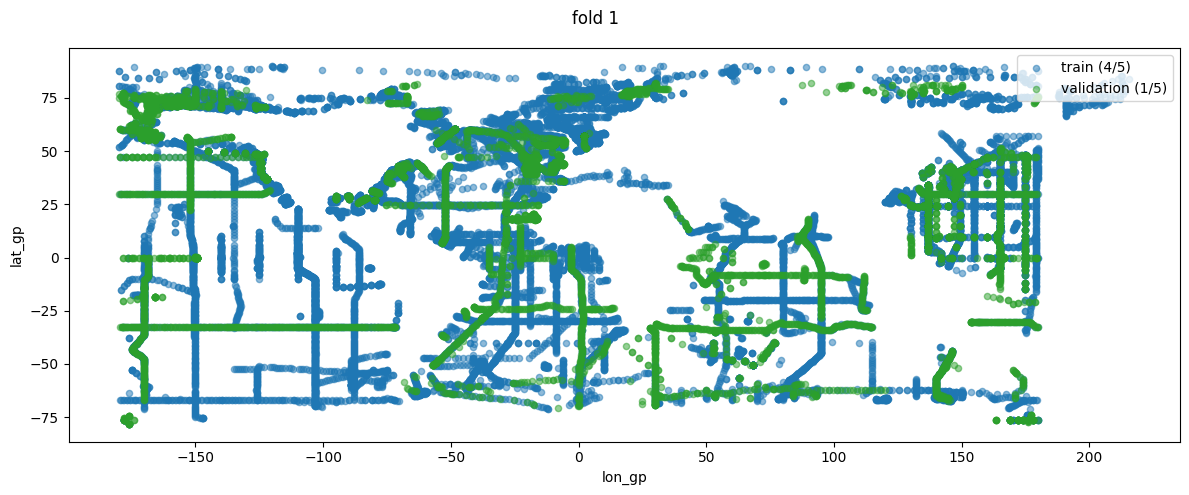

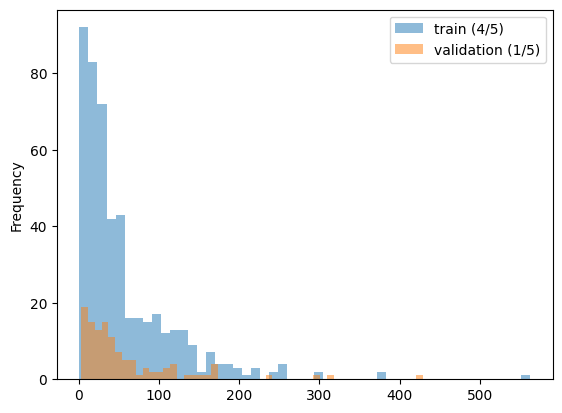

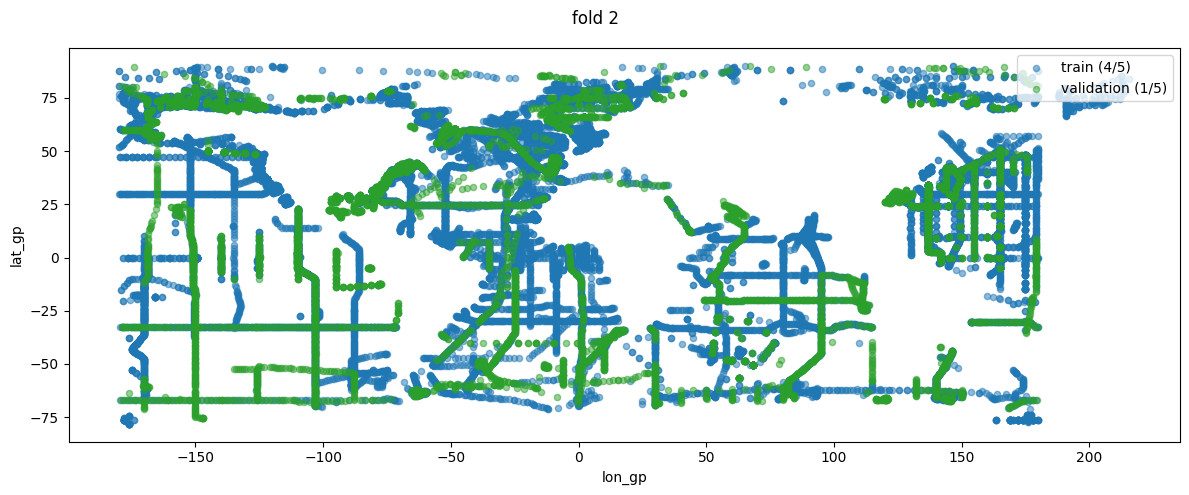

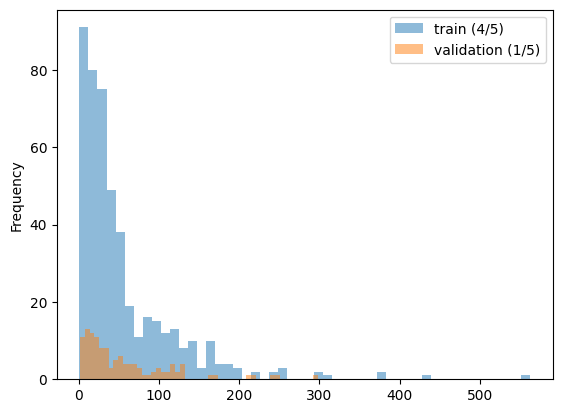

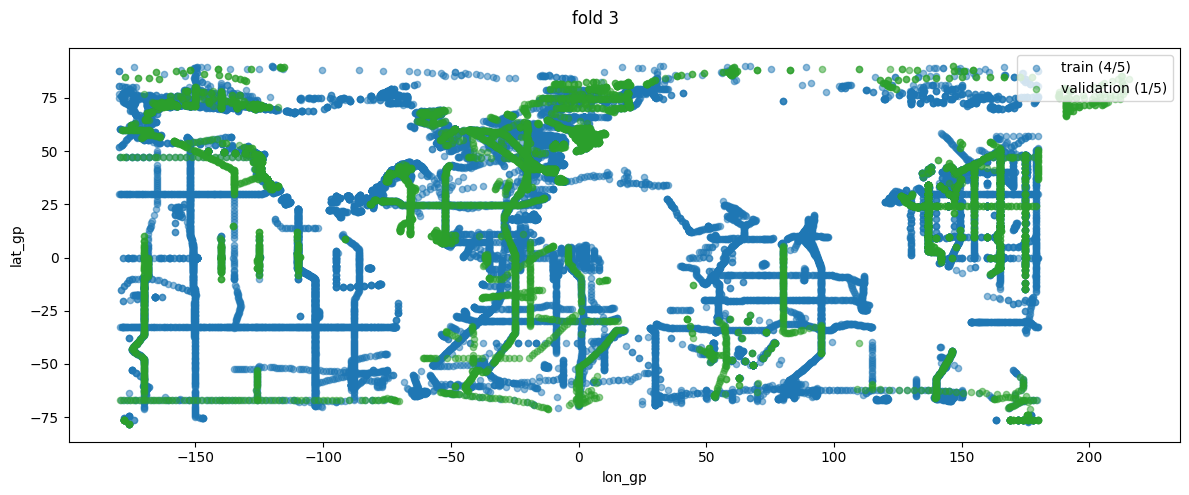

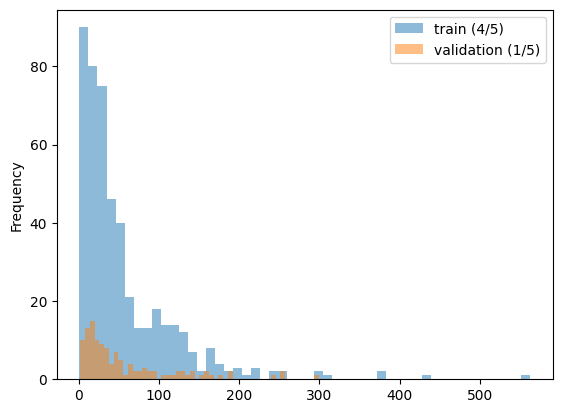

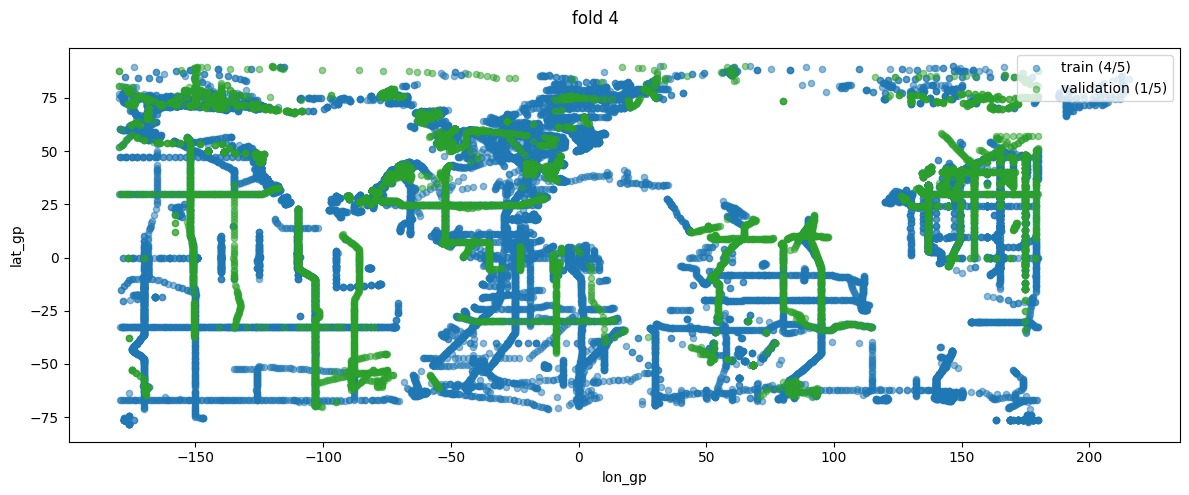

In [10]:
cv_splitter = model_selection.StratifiedGroupKFold(n_splits=5)
cv_splits = list(cv_splitter.split(train_split_df, train_split_df['salinity_bin'], groups=train_split_df["expocode_gp"]))

# Extract the first validation split from cv_splits
cv_folds = dict()

for i, (train_folds_idx, validation_fold_idx) in enumerate(cv_splits):
    
    # Create the eval_set using the validation data
    
    # 'train_pool': train_folds_pool,
    # 'eval_pool': validation_fold_pool,
        
    # train_folds_pool = cb.Pool(data = x_train.iloc[train_folds_idx], label = y_train.iloc[train_folds_idx])
    # validation_fold_pool = cb.Pool(data = x_train.iloc[validation_fold_idx], label = y_train.iloc[validation_fold_idx])
    
    cv_folds[f"fold{i}"] = {
        'x_train': x_train.iloc[train_folds_idx],
        'y_train': y_train.iloc[train_folds_idx],
        'x_validation' : x_train.iloc[validation_fold_idx],
        'y_validation': y_train.iloc[validation_fold_idx],
        'train_idx': train_folds_idx,
        'eval_idx': validation_fold_idx
    }
    
    plot_split(train_split_df, 
               train_folds_idx, validation_fold_idx, 
               label_train='train (4/5)', label_eval='validation (1/5)', 
               eval_color="C2",
               title = f"fold {i}")

In [21]:
# # save train-test split to files
# x_train.to_parquet("X_train.parquet")
# x_test.to_parquet("X_test.parquet")
# y_train.to_parquet("y_train.parquet")
# y_test.to_parquet("y_test.parquet")

# CatBoost

In [22]:
import catboost as cb

train_pool = cb.Pool(data =x_train, label= y_train )
test_pool = cb.Pool(data = x_test, label =y_test)

baseline (no CV, no tuning, tested on test set)

In [23]:
# Fit the CatBoost model with eval_set
RMSE_model = cb.CatBoostRegressor(iterations=10, loss_function='RMSE', custom_metric = ['RMSE', 'MAE', 'R2'])
uncertRMSE_model = cb.CatBoostRegressor(iterations=10, loss_function='RMSEWithUncertainty', custom_metric = ['RMSE', 'MAE', 'R2'])

# model.save_model(fname,
#            format="cbm",
#            export_parameters=None,
#            pool=None)

training with the whole dataset

In [24]:
# # train with the whole training dataset
# RMSE_model = model.fit(train_pool, plot = True)
# uncertRMSE_model.fit(train_pool, eval_set=test_pool , logging_level='Info', plot=True)


In [25]:
# yhat_train = model.predict(x_train)
# yhat_test = model.predict(x_test)

# df_metrics = pd.DataFrame({
#     'r2_score': {
#         'train': metrics.r2_score(y_train, yhat_train), 
#         'test': metrics.r2_score(y_test, yhat_test)
#     },
#     'rmse': {
#         'train': metrics.root_mean_squared_error(y_train, yhat_train), 
#         'test': metrics.root_mean_squared_error(y_test, yhat_test)
#     },
#     'mae': {
#         'train': metrics.mean_absolute_error(y_train, yhat_train), 
#         'test': metrics.mean_absolute_error(y_test, yhat_test)
#     },
#     'bias': {
#         'train': (yhat_train - y_train).mean(), 
#         'test': (yhat_test - y_test).mean()
#     }
# })

# df_metrics.T.round(2)

# names: list[str] = model.feature_names_  # type: ignore
# values = model.feature_importances_

# pd.Series({k: float(v) for k, v in zip(names, values, strict=True)}).sort_values(ascending=False)

With QC based sample weighting

In [26]:
# sample_weights = something with qc or flags
# weigthed_train_pool = cb.Pool( x_train, y_train, weights = sample_weights)
# weigthed_test_pool = cb.Pool(x_test, y_test)

with cross validation

In [27]:
# def cv_assessment(model: cb.CatBoostRegressor, cv_folds : dict):
    
#     cv_scores_dict = dict()
#     cv_predictions_dict = dict()
    
#     for i, fold in enumerate(cv_folds.keys()):
        
#         train_folds_pool = cb.Pool(data = cv_folds[fold]['x_train'], label = cv_folds[fold]['y_train'])
#         validation_fold_pool = cb.Pool(data = cv_folds[fold]['x_validation'], label = cv_folds[fold]['y_validation'])   

#         model.fit(train_folds_pool, eval_set=validation_fold_pool)
        
#         train_predictions = model.predict(train_folds_pool)
#         validation_predictions = model.predict(validation_fold_pool)
        
#         best_scores = model.get_best_score()
#         best_scores['learn']['best_RMSE_iteration'] = np.nan
#         best_scores['validation']['best_RMSE_iteration'] = model.get_best_iteration()
        
#         scores = model.get_evals_result()
        
#         # update dictionaries
#         cv_scores_dict[fold] = {'best_scores': pd.DataFrame.from_dict(best_scores),
#                                 'learn_scores' : pd.DataFrame.from_dict(scores['learn']),
#                                 'validation_scores' : pd.DataFrame.from_dict(scores['validation'])}
        
        
#         cv_predictions_dict[fold] = {'learn': train_predictions,
#                                   'validation': validation_predictions
#                                   }
        
        
            
#     return cv_predictions_dict, cv_scores_dict


# RMSEpredictions, cv_scores_dict = cv_assessment(RMSE_model, cv_folds=cv_folds)

In [28]:
def cv_cb_assessment(model: cb.CatBoostRegressor, cv_folds : dict):
    
    cv_scores_dict = dict()
    cv_predictions_dict = dict()
    
    for i, fold in enumerate(cv_folds.keys()):
        
        y_train_folds = cv_folds[fold]['y_train']
        x_train_folds = cv_folds[fold]['x_train']
        
        y_validation = cv_folds[fold]['y_validation']
        x_validation = cv_folds[fold]['x_validation']
        
        
        train_folds_pool = cb.Pool(data = x_train_folds , label = y_train_folds)
        validation_fold_pool = cb.Pool(data = x_validation, label = y_validation)   

        model.fit(train_folds_pool, eval_set=validation_fold_pool)
        
        train_predictions = model.predict(train_folds_pool)
        validation_predictions = model.predict(validation_fold_pool)
        
        scores = model.get_evals_result()
        learn_progression = pd.DataFrame.from_dict(scores['learn'])
        validation_progression = pd.DataFrame.from_dict(scores['validation'])
        
        final_scores = pd.DataFrame({
            
            'learn': {
                'final_MAE': learn_progression['MAE'].iloc[-1],
                'final_R2':learn_progression['R2'].iloc[-1],
                'final_RMSE': learn_progression['RMSE'].iloc[-1],
                'bias': (train_predictions - y_train_folds).mean()
            },
            
            'validation':{
                'final_MAE': validation_progression['MAE'].iloc[-1],
                'final_R2':validation_progression['R2'].iloc[-1],
                'final_RMSE': validation_progression['RMSE'].iloc[-1],
                'bias': (validation_predictions - y_validation).mean()
            }

        })

        
        best_scores_dict = model.get_best_score()
        best_scores_dict['learn']['best_RMSE_iteration'] = np.nan
        best_scores_dict['validation']['best_RMSE_iteration'] = model.get_best_iteration()
        best_scores = (pd.DataFrame.from_dict(best_scores_dict)
                       .rename(index=lambda x: f"best_{x}")
        )
        
        scores = pd.concat([final_scores, best_scores])
        
        
        # update dictionaries
        cv_scores_dict[fold] = {'scores': scores,
                                'learn_progression' : learn_progression,
                                'validation_progression' : validation_progression}
        
        
        cv_predictions_dict[fold] = {
            'learn': 
                {
                    'predictions' : train_predictions,
                    'residuals':  train_predictions - y_train_folds
                },
            
            'validation': 
                {
                    'predictions': validation_predictions,
                    'residuals': validation_predictions-y_validation
                }
        }
        
        
    return cv_predictions_dict, cv_scores_dict
 
def cv_folds_comparison(cv_scores_dict, fold_type = 'validation'):
    
    compared_scores = pd.DataFrame()
    
    for fold in cv_scores_dict.keys():
        
        fold_scores = cv_scores_dict[fold]['scores'][fold_type]
        fold_scores.name = fold
        compared_scores = pd.concat([compared_scores, fold_scores], axis = 1)
        
    compared_scores['cv_avg'] = compared_scores.mean(axis=1) 
    
    return compared_scores
        
     

    


# df_metrics = pd.DataFrame({
#     'r2_score': {
#         'train': metrics.r2_score(y_train, yhat_train), 
#         'test': metrics.r2_score(y_test, yhat_test)
#     },
#     'rmse': {
#         'train': metrics.root_mean_squared_error(y_train, yhat_train), 
#         'test': metrics.root_mean_squared_error(y_test, yhat_test)
#     },
#     'mae': {
#         'train': metrics.mean_absolute_error(y_train, yhat_train), 
#         'test': metrics.mean_absolute_error(y_test, yhat_test)
        
#     },


#     'best_r2_score': {
#         'train': metrics.r2_score(y_train, yhat_train), 
#         'test': metrics.r2_score(y_test, yhat_test)
#     },
#     'best_rmse': {
#         'train': metrics.root_mean_squared_error(y_train, yhat_train), 
#         'test': metrics.root_mean_squared_error(y_test, yhat_test)
#     },
#     'best_mae': {
#         'train': metrics.mean_absolute_error(y_train, yhat_train), 
#         'test': metrics.mean_absolute_error(y_test, yhat_test)
        
#     },
    
# })

# df_metrics.T.round(2)


In [29]:
# model_results = {

#     "xgboost": {
#         "y_pred_test": y_pred_test,
#         "metrics": metrics,
#         "cv_scores": cv_scores
#     },

#     "random_forest": {
#         "y_pred_test": y_pred_test,
#         "metrics": metrics,
#         "cv_scores": cv_scores
#     }
# }

In [30]:
learn_scores_RMSEmodel, validation_scores_RMSEmodel = cv_folds_comparison(cv_scores_dict)
learn_scores_RMSEmodel

NameError: name 'cv_scores_dict' is not defined

In [ ]:
validation_scores_RMSEmodel

In [ ]:
cv_scores_dict['fold2']['scores']


In [ ]:
RMSEpredictions['fold0']['learn']

In [ ]:
cv_scores_dict['fold0']['validation_scores']

In [ ]:
colors = plt.cm.viridis(np.linspace(0, 1, len(cv_folds.keys())))

# Plot MAE
fig, ax = plt.subplots(figsize=[12, 5])
for i, fold in enumerate(cv_folds.keys()):
    c = colors[i]  # Assign a unique color for each fold
    cv_scores_dict[fold]['validation_scores']['MAE'].plot(label=f"{fold} (validation)", ax=ax, color=c)
    cv_scores_dict[fold]['learn_scores']['MAE'].plot(label=f"{fold} (train)", linestyle='dashed', ax=ax, color=c)
ax.legend()
ax.grid()
fig.suptitle('MAE')
plt.show()

# Plot R2
fig, ax = plt.subplots(figsize=[12, 5])
for i, fold in enumerate(cv_folds.keys()):
    c = colors[i]  # Assign a unique color for each fold
    cv_scores_dict[fold]['validation_scores']['R2'].plot(label=f"{fold} (validation)", ax=ax, color=c)
    cv_scores_dict[fold]['learn_scores']['R2'].plot(label=f"{fold} (train)", linestyle='dashed', ax=ax, color=c)
ax.legend()
ax.grid()
fig.suptitle('R2')
plt.show()

# Plot RMSE
fig, ax = plt.subplots(figsize=[12, 5])
for i, fold in enumerate(cv_folds.keys()):
    c = colors[i]  # Assign a unique color for each fold
    cv_scores_dict[fold]['validation_scores']['RMSE'].plot(label=f"{fold} (validation)", ax=ax, color=c)
    cv_scores_dict[fold]['learn_scores']['RMSE'].plot(label=f"{fold} (train)", linestyle='dashed', ax=ax, color=c)
ax.legend()
ax.grid()
fig.suptitle('RMSE')
plt.show();


In [ ]:
# #store pools in a list
# cv_pools_list = [tuple([train_folds_pool,validation_fold_pool])]


    



# uncertRMSE_rmse = np.sqrt(((uncertRMSEpreds - y[validation_fold_idx])**2).mean())
# RMSE_rmse = np.sqrt(((RMSEpreds - y[validation_fold_idx])**2).mean())

# ["validation"]["RMSE"]
# scores.append(score)


# scores_RMSE_model.append(rmse)
# scores_uncertRMSE_model.append(rmse)

# print("CV RMSE:", np.mean(scores))
    
#     # Create the eval_set using the validation data

    
#     uncertRMSE_model.fit(train_folds_pool, eval_set=validation_fold_pool)
#     uncertRMSEpreds = uncertRMSE_model.predict(validation_fold_pool)
#     uncertRMSE_scores = uncertRMSE_model.get_best_score()

# Random forest regression


In [11]:
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
import json
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
import joblib
import catboost as cb



In [32]:
current_path = Path.cwd()
parent_path = current_path.parent

model_dir = parent_path / f"trained_models"
model_dir.mkdir(exist_ok=True)

rf_dir = model_dir/f"RandomForest"
rf_dir.mkdir(exist_ok=True)
cb_dir = model_dir/f"Catboost"
cb_dir.mkdir(exist_ok=True)
gp_dir = model_dir/f"GaussianProcesses"
gp_dir.mkdir(exist_ok=True)

In [73]:
def training(model, x_train, y_train, x_eval, y_eval, filepath = None, filename = None, export_metadata = False):
    
    model.fit(x_train, y_train)
    
    feature_importance_df = pd.DataFrame([model.feature_importances_], columns=model.feature_names_in_)

    y_pred = model.predict(x_eval)
    residuals = y_pred - y_eval

    # Reset index to avoid duplicate label issues
    residuals_df = pd.DataFrame({
        'y_pred': pd.Series(y_pred).reset_index(drop=True),
        'y_eval': pd.Series(y_eval).reset_index(drop=True),
        'residuals': pd.Series(residuals).reset_index(drop=True),
    })

    eval_scores_dict = {
            'MAE': {'eval_set': mean_absolute_error(y_eval, y_pred)},
            'R2':  {'eval_set': r2_score(y_eval, y_pred)},
            'RMSE': { 'eval_set': root_mean_squared_error(y_eval, y_pred)},
            'bias': { 'eval_set': residuals.mean()}
        }

    eval_scores = pd.DataFrame(eval_scores_dict)

    if filepath is not None:
        # Export model
        joblib.dump(model, f"{filepath}/{filename}.joblib")

        # Export residuals
        residuals_df.to_csv(path_or_buf=f"{filepath}/{filename}_residuals.csv", index=False)

        # Export metadata
        if export_metadata:
            metadata = {
                "model_type": type(model).__name__,  # Convert to string
                "features": list(x_train.columns),
                "params": model.get_params(),
                "eval_scores": eval_scores_dict,
                "feature_importance": feature_importance_df
            }

            with open(f"{filepath}/{filename}_metadata.json", "w") as f:
                json.dump(metadata, f, indent=2)

    return model, residuals_df, eval_scores, feature_importance_df

def cv_assessment(model, cv_folds: dict, filepath, filename, export_fold_metadata=False):
    
    filepath.mkdir(exist_ok=True)
    
    cv_eval_scores = pd.DataFrame()
    cv_feature_importance = pd.DataFrame()
    cv_trained_models_dict = dict()

    for fold in cv_folds.keys():
        fold_path = filepath / f"{fold}"
        fold_path.mkdir()

        x_train_fold = cv_folds[fold]['x_train']
        y_train_fold = cv_folds[fold]['y_train']
        x_eval_fold = cv_folds[fold]['x_validation']
        y_eval_fold = cv_folds[fold]['y_validation']

        fold_trained_model, fold_predictions_df, fold_eval_scores, fold_feat_importance_df = (
            training(
                model,
                x_train_fold,
                y_train_fold,
                x_eval_fold,
                y_eval_fold,
                filepath=fold_path,
                filename=filename,
                export_metadata=export_fold_metadata,
            )
        )

        cv_trained_models_dict[fold]= {'predictions_df': fold_predictions_df,
                                       'trained_regressor': fold_trained_model,
                                       'feature_importance_df': fold_feat_importance_df}

        fold_eval_scores = fold_eval_scores.rename(index={'eval_set': fold})
        cv_eval_scores = pd.concat([cv_eval_scores, fold_eval_scores], axis=0)
        
        fold_feat_importance_df = fold_feat_importance_df.reset_index(names=fold)
        cv_feature_importance = pd.concat([cv_feature_importance, fold_feat_importance_df], axis=0)
        
    cv_eval_scores_transpose = cv_eval_scores.T
    cv_eval_scores_transpose['avg'] = cv_eval_scores.T.mean(axis=1)
    cv_eval_scores = cv_eval_scores_transpose.T

    # Save the evaluation scores to a file
    cv_eval_scores.to_csv(path_or_buf=f"{filepath}/{filename}_cv_eval_scores.csv", index=True)
    
    

    return cv_trained_models_dict, cv_eval_scores


In [29]:
rf_regressor = RandomForestRegressor(n_estimators=5, random_state=42)
simple_rf_dir = rf_dir/f"SimpleRandomForest"
simple_rf_dir.mkdir(exist_ok=True)
trained_simple_rf, residuals, eval_scores = training(rf_regressor, x_train, y_train, x_test, y_test,  filepath=simple_rf_dir, filename= f"simple_rf", export_metadata=True)
    

In [30]:
eval_scores

,MAE,R2,RMSE,bias
eval_set,13.729698,0.890049,34.537845,0.871448


In [15]:
# rf_cv_dict, rf_eval_scores = cv_assessment(rf_regressor,cv_folds, filepath= rf_dir/f"cv_simple_rf")

import catboost as cb
RMSE_model = cb.CatBoostRegressor(iterations=10, loss_function='RMSE')
cv_cb_dir = cb_dir/f"simple_cv"
cv_cb_dir.mkdir(exist_ok=True)

fcv_trained_models, cv_eval_scores = cv_assessment(RMSE_model, cv_folds, filepath= cv_cb_dir, filename = f"cv_simple_cbRMSE", export_fold_metadata=True)


Learning rate set to 0.5
0:	learn: 77.4897284	total: 62.5ms	remaining: 562ms
1:	learn: 55.3867080	total: 70.5ms	remaining: 282ms
2:	learn: 43.8554644	total: 79.5ms	remaining: 186ms
3:	learn: 39.7172465	total: 88.9ms	remaining: 133ms
4:	learn: 37.3122685	total: 96.8ms	remaining: 96.8ms
5:	learn: 36.1160795	total: 103ms	remaining: 68.9ms
6:	learn: 35.2479384	total: 110ms	remaining: 47.1ms
7:	learn: 34.1910621	total: 116ms	remaining: 29.1ms
8:	learn: 33.2631237	total: 122ms	remaining: 13.6ms
9:	learn: 32.7493113	total: 128ms	remaining: 0us
Learning rate set to 0.5
0:	learn: 74.7805931	total: 10.5ms	remaining: 94.7ms
1:	learn: 53.5377086	total: 18.2ms	remaining: 72.7ms
2:	learn: 43.9528729	total: 26.1ms	remaining: 60.8ms
3:	learn: 39.8217779	total: 33.5ms	remaining: 50.3ms
4:	learn: 37.5966494	total: 41.2ms	remaining: 41.2ms
5:	learn: 36.2727581	total: 47.8ms	remaining: 31.9ms
6:	learn: 34.3141191	total: 54.4ms	remaining: 23.3ms
7:	learn: 33.6715151	total: 59.9ms	remaining: 15ms
8:	learn: 

In [16]:
cv_eval_scores

,MAE,R2,RMSE,bias
fold0,17.287982,0.898969,30.963191,-3.244223
fold1,16.267072,0.931909,27.936409,1.926331
fold2,21.339673,0.823869,54.211388,-2.252826
fold3,19.239206,0.857211,38.062984,-2.542622
fold4,20.601982,0.876409,52.634778,7.991635
avg,18.947183,0.877673,40.761750,0.375659


In [34]:
model_RMSE = cb.CatBoostRegressor(iterations=10, loss_function='RMSE')
model_RMSEUncert = cb.CatBoostRegressor(iterations=10, loss_function='RMSE')
model_RandomForest = RandomForestRegressor(n_estimators=5, random_state=42)

models_dict = {
    
    'Catboost_RMSE': {
        'regressor': model_RMSE,
        'dir': cb_dir/f"RMSE_iter10",
        'filename': 'RMSE_iter10'
    },
    
    'Catboost_RMSEUncert': {
        'regressor': model_RMSEUncert,
        'dir': cb_dir/f"RMSEUncert_iter10",
        'filename': 'RMSEUncert_iter10'
    },
    
    'RandomForest': {
        'regressor': model_RandomForest,
        'dir': rf_dir/f"RandomForest_nest5",
        'filename': 'RandomForest_nest5'
    }
}

for model_name in models_dict.keys():
    cv_trained_models_dict, cv_eval_scores = (cv_assessment(
        model = models_dict[model_name]['regressor'],
        cv_folds = cv_folds,
        filepath = models_dict[model_name]['dir'],
        filename = models_dict[model_name]['filename'],
        export_fold_metadata = True
    ))
    
    models_dict[model_name]['cv_models'] = cv_trained_models_dict
    models_dict[model_name]['eval_scores_cv'] = cv_eval_scores



Learning rate set to 0.5
0:	learn: 77.4897284	total: 64.9ms	remaining: 584ms
1:	learn: 55.3867080	total: 73.5ms	remaining: 294ms
2:	learn: 43.8554644	total: 82ms	remaining: 191ms
3:	learn: 39.7172465	total: 90ms	remaining: 135ms
4:	learn: 37.3122685	total: 98.7ms	remaining: 98.7ms
5:	learn: 36.1160795	total: 106ms	remaining: 70.8ms
6:	learn: 35.2479384	total: 113ms	remaining: 48.5ms
7:	learn: 34.1910621	total: 121ms	remaining: 30.3ms
8:	learn: 33.2631237	total: 128ms	remaining: 14.2ms
9:	learn: 32.7493113	total: 134ms	remaining: 0us
Learning rate set to 0.5
0:	learn: 74.7805931	total: 10.3ms	remaining: 92.7ms
1:	learn: 53.5377086	total: 18.6ms	remaining: 74.3ms
2:	learn: 43.9528729	total: 26.3ms	remaining: 61.3ms
3:	learn: 39.8217779	total: 33.6ms	remaining: 50.4ms
4:	learn: 37.5966494	total: 40.9ms	remaining: 40.9ms
5:	learn: 36.2727581	total: 47.8ms	remaining: 31.9ms
6:	learn: 34.3141191	total: 54ms	remaining: 23.2ms
7:	learn: 33.6715151	total: 60.5ms	remaining: 15.1ms
8:	learn: 32.4

In [23]:
print(models_dict['Catboost_RMSEUncert'].keys())

dict_keys(['regressor', 'dir', 'filename', 'cv_models', 'eval_scores_cv'])


In [18]:
models_dict['Catboost_RMSEUncert']['eval_scores_cv']

,MAE,R2,RMSE,bias
fold0,17.287982,0.898969,30.963191,-3.244223
fold1,16.267072,0.931909,27.936409,1.926331
fold2,21.339673,0.823869,54.211388,-2.252826
fold3,19.239206,0.857211,38.062984,-2.542622
fold4,20.601982,0.876409,52.634778,7.991635
avg,18.947183,0.877673,40.761750,0.375659


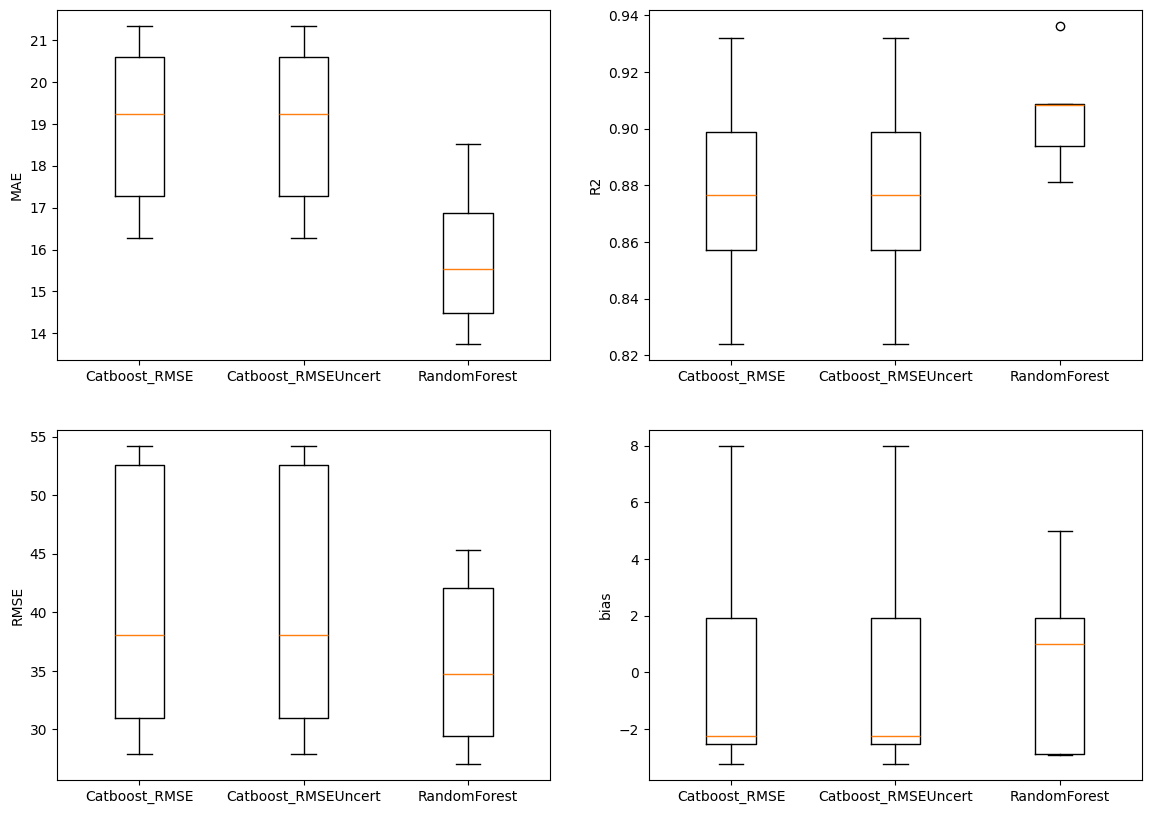

In [35]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize=(14, 10))
ax = ax.flatten()

models_labels = list(models_dict.keys())

for i, metric in enumerate(['MAE','R2','RMSE','bias']):
    
    models_scores= [models_dict[model_name]['eval_scores_cv'][metric].drop(index = 'avg') for model_name in models_dict.keys()]
        
    ax[i].boxplot(models_scores, tick_labels = models_labels)
    ax[i].set_ylabel(metric)

plt.show()

In [48]:
def plot_actual_vs_predicted(y_true, y_pred, ax = None, fig = None, title = 'Actual vs predicted', label = ''):

    if ax == None:
        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(14, 10))

    ax.scatter(y_true, y_pred, alpha=0.6, label = label)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(title)

    if len(fig.axes) == 1:
        fig.legend()
        plt.show();


def plot_residuals_vs_predicted(residuals, y_pred, ax = None, fig = None, title = 'Residuals vs Predicted', label = ''):

    if ax == None:
        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(14, 10))

    ax.scatter(y_pred, residuals, alpha=0.6, label = label)
    ax.axhline(0, linestyle="--")

    ax.set_xlabel("Residuals")
    ax.set_ylabel("Predicted")
    ax.set_title(title)

    if len(fig.axes) == 1:
        fig.legend()
        plt.show();   
        
def plot_residuals_distribution(residuals, ax = None, fig = None, title = 'Residuals distribution', label = ''):
    
    import seaborn as sns 
    
    if ax == None:
        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(14, 10))

    sns.histplot(residuals, kde=True, ax= ax, alpha = 0.6, label = label)
    ax.axhline(0, linestyle="--")

    ax.set_xlabel("Residuals")
    ax.set_title(title)

    if len(fig.axes) == 1:
        fig.legend()
        plt.show();   


def plot_qq_residuals(residuals, ax=None, fig=None, title='Q-Q Plot of Residuals', label=None):

    import numpy as np
    import scipy.stats as stats
    import matplotlib.pyplot as plt

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(14,10))

    # Compute theoretical quantiles and ordered residuals
    (theoretical_q, ordered_residuals), _ = stats.probplot(residuals, dist="norm")

    # Plot dataset (matplotlib will auto-cycle colors)
    ax.scatter(theoretical_q, ordered_residuals, alpha=0.6, label=label)

    # Draw reference line only once
    if len(ax.lines) == 0:
        min_q = theoretical_q.min()
        max_q = theoretical_q.max()
        ax.plot([min_q, max_q], [min_q, max_q], linestyle="--", color="black")

    ax.set_title(title)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")

    if label is not None:
        ax.legend()

    if fig is not None and len(fig.axes) == 1:
        plt.show()
        
        

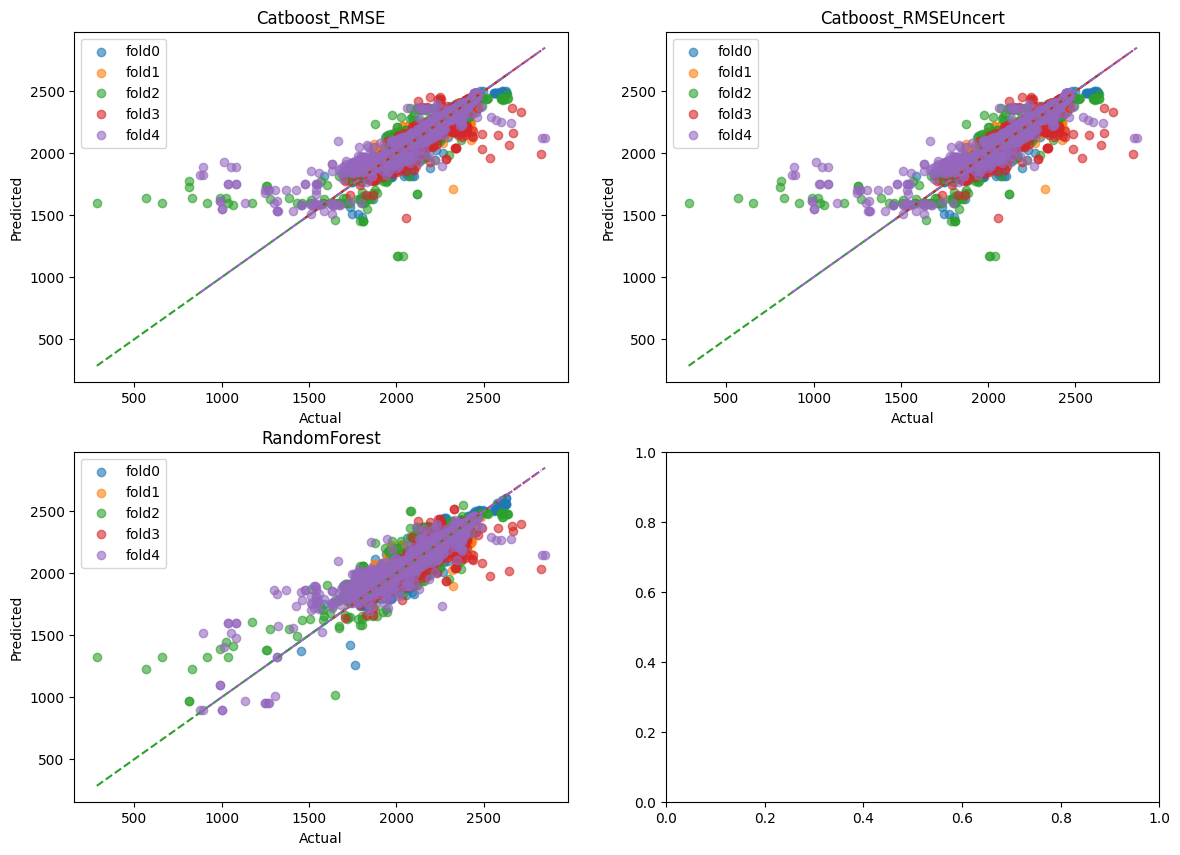

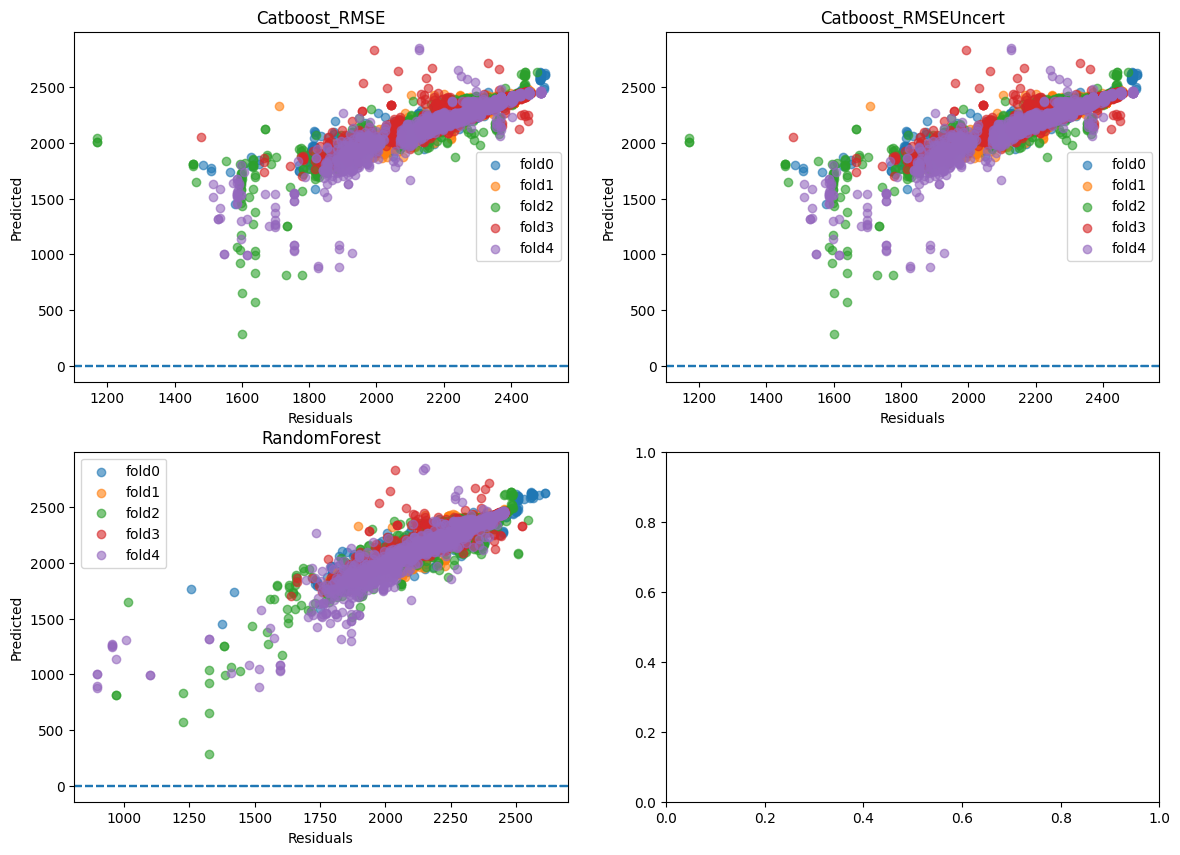

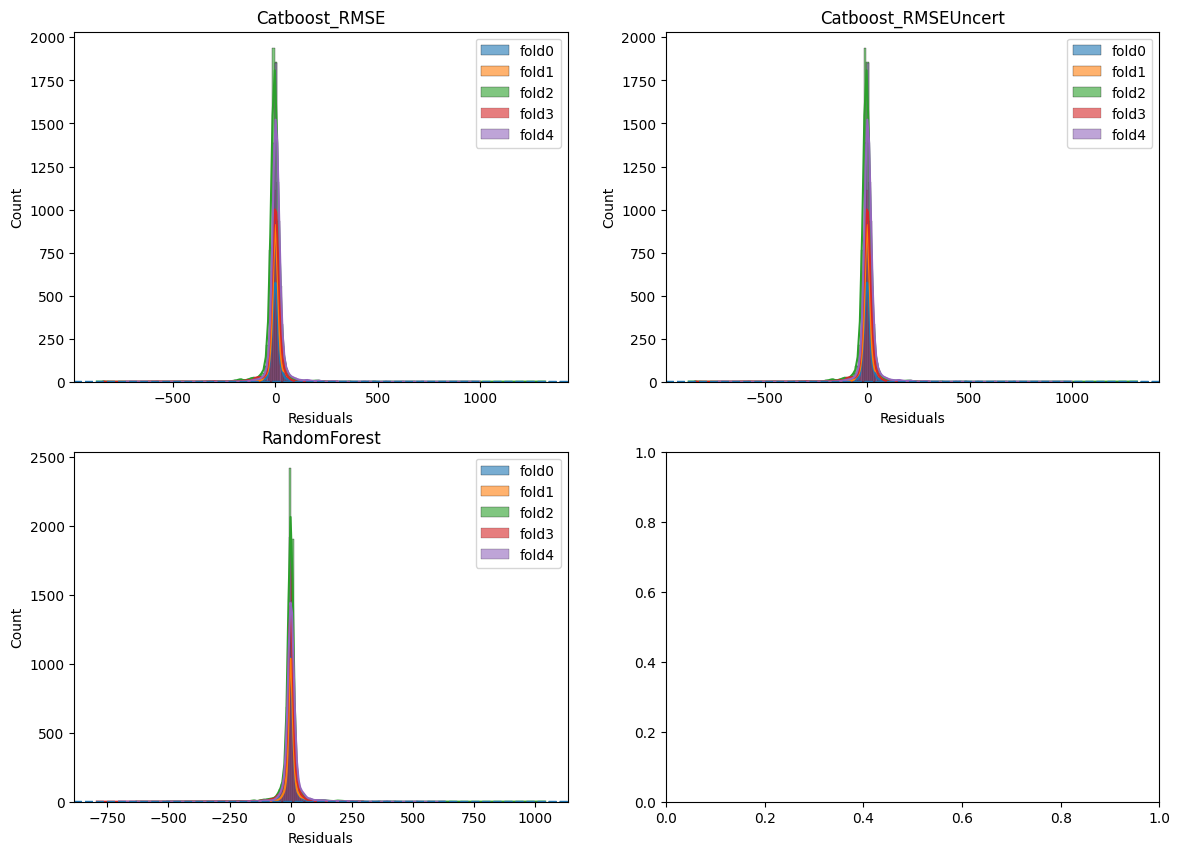

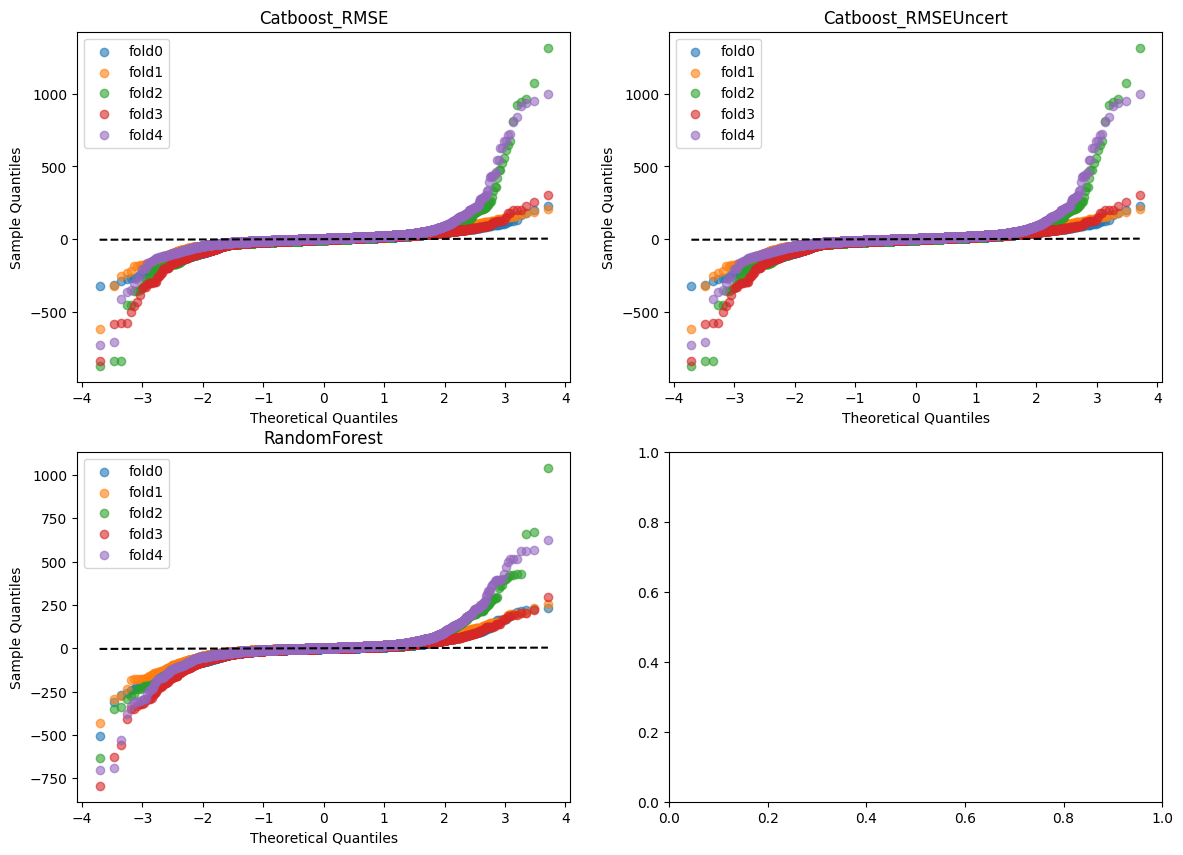

In [49]:
fig1, ax1 = plt.subplots(nrows = 2, ncols = 2, figsize=(14, 10))
ax1 = ax1.flatten()

fig2, ax2 = plt.subplots(nrows = 2, ncols = 2, figsize=(14, 10))
ax2 = ax2.flatten()

fig3, ax3 = plt.subplots(nrows = 2, ncols = 2, figsize=(14, 10))
ax3 = ax3.flatten()

fig4, ax4 = plt.subplots(nrows = 2, ncols = 2, figsize=(14, 10))
ax4 = ax4.flatten()

for i, model_name in enumerate(models_dict.keys()):
    
    for fold in models_dict[model_name]['cv_models'].keys():
        y_true = models_dict[model_name]['cv_models'][fold]['predictions_df']['y_eval']
        y_pred = models_dict[model_name]['cv_models'][fold]['predictions_df']['y_pred']
        residuals = models_dict[model_name]['cv_models'][fold]['predictions_df']['residuals']
        
        plot_actual_vs_predicted(y_true, y_pred, ax = ax1[i], fig = fig1, title=model_name, label = fold)
        ax1[i].legend()
        
        plot_residuals_vs_predicted(y_true, y_pred, ax = ax2[i], fig = fig2, title=model_name, label = fold)
        ax2[i].legend()
        
        plot_residuals_distribution(residuals, ax = ax3[i], fig = fig3, title=model_name, label = fold)
        ax3[i].legend()
        
        plot_qq_residuals(residuals, ax = ax4[i], fig = fig4, title=model_name, label = fold)
        ax4[i].legend()


plt.show();

To save your variables and restore them later in a Jupyter Notebook, you can use the `pickle` or `joblib` libraries to serialize and save your variables to a file. Here's how you can manage this:

### 1. **Save Variables to a File**
Before your session ends, save your variables to a file:



In [ ]:
import pickle

# Save variables to a file
variables_to_save = {
    'model': model_RandomForest,
    'features': features,
    'importance': importance,
    # Add other variables you want to save
}

with open('saved_variables.pkl', 'wb') as f:
    pickle.dump(variables_to_save, f)



### 2. **Load Variables When You Reconnect**
When you reconnect, load the variables back into your session:



In [ ]:
import pickle

# Load variables from the file
with open('saved_variables.pkl', 'rb') as f:
    loaded_variables = pickle.load(f)

# Access your variables
model_RandomForest = loaded_variables['model']
features = loaded_variables['features']
importance = loaded_variables['importance']



### 3. **Alternative: Use `joblib` for Large Objects**
If you are working with large objects (e.g., models), you can use `joblib` for better performance:



In [ ]:
from joblib import dump, load

# Save variables
dump(variables_to_save, 'saved_variables.joblib')

# Load variables
loaded_variables = load('saved_variables.joblib')



### 4. **Automate Saving and Loading**
You can add a cell at the beginning of your notebook to check if a saved file exists and load it automatically:



In [ ]:
import os
import pickle

if os.path.exists('saved_variables.pkl'):
    with open('saved_variables.pkl', 'rb') as f:
        loaded_variables = pickle.load(f)
    print("Variables loaded successfully!")
else:
    print("No saved variables found.")



This way, you can save your progress and restore it seamlessly after a disconnection. Let me know if you'd like me to add this to your notebook!

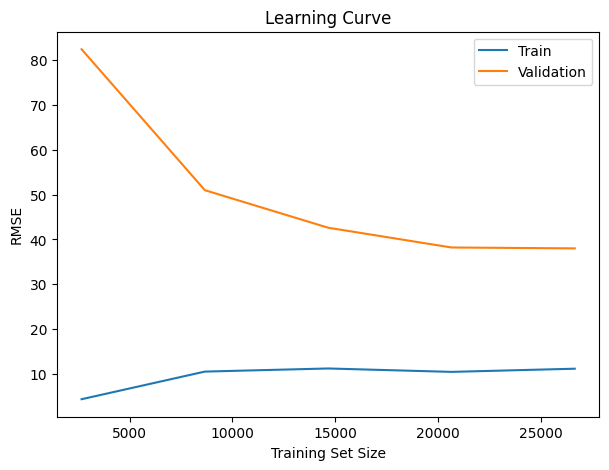

In [ ]:
# from sklearn.model_selection import learning_curve


# def plot_learning_curve(model, X, y):

#     train_sizes, train_scores, val_scores = learning_curve(
#         model,
#         X,
#         y,
#         cv=5,
#         scoring="neg_root_mean_squared_error"
#     )

#     train_mean = -train_scores.mean(axis=1)
#     val_mean = -val_scores.mean(axis=1)

#     plt.figure(figsize=(7,5))

#     plt.plot(train_sizes, train_mean, label="Train")
#     plt.plot(train_sizes, val_mean, label="Validation")

#     plt.xlabel("Training Set Size")
#     plt.ylabel("RMSE")

#     plt.title("Learning Curve")
#     plt.legend()

#     plt.show()
    
# plot_learning_curve(model_RandomForest, x_train, y_train)

In [ ]:
def plot_feature_importance(feature_names, importance):

    import seaborn as sns
    
    df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })

    df = df.sort_values("importance", ascending=False)

    plt.figure(figsize=(7,6))


    sns.barplot(
        data=df.head(20),
        x="importance",
        y="feature"
    )

    plt.title("Feature Importance (Top 20)")

    plt.show()
    
    
importance = model.feature_importances_

,fold,temp_gp,salinity_gp,mld_soda,sst_cciT,ice_cciT,ssh_adt_cmems,ssh_sla_cmems,mld_glorys,chl_globcolour
0,0,0.010674,0.911503,0.009541,0.011458,0.002724,0.020944,0.007914,0.008754,0.016488


array(['temp_gp', 'salinity_gp', 'mld_soda', 'sst_cciT', 'ice_cciT',
       'ssh_adt_cmems', 'ssh_sla_cmems', 'mld_glorys', 'chl_globcolour'],
      dtype=object)